In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import json
import math
import joblib


#########################
# import data and model #
#########################


#gbdt_model = joblib.load("gbdt_model_small_stat_newTS_multiplane_newvars.pkl")
gbdt_model = joblib.load("gbdt_model_small_stat_newTS_newvars_onlycoll.pkl")

#gbdt_model = joblib.load("gbdt_model_small_stat_newTS.pkl")

#file = uproot.open("run9435.root")
file = uproot.open("data_struct_70percent_corretto.root")
#file = uproot.open("data_struct_provaMaria.root")

slices = file['tree'].arrays(library='ak')

dumpNuEfile = 'dumpNuE_70percent.txt'
#dumpNuEfile = 'dumpNuE_100percent.txt'
#dumpNuEfile = 'dumpNuE_provaMaria.txt'

#print(json.dumps(ak.to_list(slices[0]), indent=2))


In [ ]:
# this only shows you how an entry of the object slice looks like!
print(json.dumps(ak.to_list(slices[0]), indent=2))

In [2]:

def find_candidate_muon_full_vectorized(slices, muon_length):
    lengths = slices['tracks.reco.length']

    chi2 = (slices['tracks.reco.chi2_as_mu'] < 30) & (slices['tracks.reco.chi2_as_pro'] > 60)
    #endy = slices['tracks.reco.end'][...,1] > 125

    #chi2_mu_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_mu'])
    #chi2_pro_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_pro'])

    mask = (
        #(~slices['is_clear_cosmic']) & # INCLUDED IN THE SLICE SELECTION
        (slices['tracks.reco.trackscore'] >= 0.5) &
        #(chi2_mu_non_nan) &
        #(chi2_pro_non_nan) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > muon_length) &
        chi2 & 
        #endy &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        #(slices['tracks.reco.is_start_contained']) 
        (slices['tracks.reco.is_end_contained']) #INCLUDED IN THE SLICE SELECTION
    )

    valid = ak.any(mask, axis=1)

    muon_idx = ak.argmax(ak.where(mask, lengths, -1), axis=1)

    muon_idx = ak.where(valid, muon_idx, -1)
    muon_idx = ak.mask(muon_idx, muon_idx != -1)
    return muon_idx


def find_candidate_muon_full_vectorized_BDT_new(slices, mu_length):
    lengths = slices['tracks.reco.length']

    mask = (
        (slices['tracks.reco.trackscore'] >= 0.5) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        (lengths > mu_length) &
        (slices['tracks.reco.all_in_1_tpc']) &
        (slices['tracks.reco.is_primary']) &
        (slices['tracks.reco.is_end_contained']) #INCLUDED IN THE SLICE SELECTION
    )

    muon_indices = ak.local_index(mask)[mask]
    return muon_indices

def find_pfp_full_vectorized(slices):
    valid_start = ~np.isnan(slices['tracks.reco.start'][...,0]) & \
                  ~np.isnan(slices['tracks.reco.start'][...,1]) & \
                  ~np.isnan(slices['tracks.reco.start'][...,2])

    valid_end = ~np.isnan(slices['tracks.reco.end'][...,0]) & \
                ~np.isnan(slices['tracks.reco.end'][...,1]) & \
                ~np.isnan(slices['tracks.reco.end'][...,2])
    
    #chi2_mu_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_mu'])
    #chi2_pro_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_pro'])

    mask = (
        (slices['tracks.reco.length'] >= 0) &
        #(chi2_mu_non_nan) &
        #(chi2_pro_non_nan) &
        (slices['tracks.reco.is_end_contained']) &
        (slices['tracks.reco.is_primary']) &
        (np.minimum(
            slices['tracks.reco.end_distance_from_reco_vertex'],
            slices['tracks.reco.start_distance_from_reco_vertex']
        ) <= 50) &
        (slices['tracks.reco.trackscore'] >= 0.4) &
        (slices['tracks.reco.start_distance_from_reco_vertex'] < 10) &
        valid_start &
        valid_end
    )

    pfp_indices = ak.local_index(mask)[mask]

    return pfp_indices

def find_shower_full_vectorized(slices):
    valid_start_x = ~np.isnan(slices['tracks.reco.start'][...,0])

    valid_end_x = ~np.isnan(slices['tracks.reco.end'][...,0]) 

    #chi2_pro_non_nan = ~np.isnan(slices['tracks.reco.chi2_as_pro'])

    trackscore_and_no_proton = ~((slices['tracks.reco.trackscore'] >= 0.4) & (slices['tracks.reco.trackscore'] < 0.5) & (slices['tracks.reco.chi2_as_pro']<100))
    

    mask = (
        (slices['tracks.reco.length'] >= 0) &
        #(chi2_pro_non_nan) &
        (slices['tracks.reco.is_primary']) &
        (np.minimum(
            slices['tracks.reco.end_distance_from_reco_vertex'],
            slices['tracks.reco.start_distance_from_reco_vertex']
        ) <= 50) &
        trackscore_and_no_proton &
        (slices['tracks.reco.trackscore']< 0.5) &
        (slices['tracks.reco.shower_energy']*1000>25) &
        valid_start_x &
        valid_end_x
    )

    showers = ak.local_index(mask)[mask]

    return showers

def find_shower_full_vectorized_BDT(slices):
    valid_start_x = ~np.isnan(slices['tracks.reco.start'][...,0])

    valid_end_x = ~np.isnan(slices['tracks.reco.end'][...,0]) 

    mask = (
        (slices['tracks.reco.length'] >= 0) &
        (slices['tracks.reco.is_primary']) &
        (np.minimum(
            slices['tracks.reco.end_distance_from_reco_vertex'],
            slices['tracks.reco.start_distance_from_reco_vertex']
        ) <= 50) &
        (slices['tracks.reco.trackscore']< 0.5) &
        (slices['tracks.reco.shower_energy']*1000>25) &
        valid_start_x &
        valid_end_x
    )

    showers = ak.local_index(mask)[mask]

    return showers

def classify_slice_newPID_v2(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    
    if slice['isinFV'] == False : return 'bad_slice'
    
    #ALL CONTAINED
    if slice['all_tracks_contained']==False : return 'bad_slice'
    #all_cont = True
    #for track in range(len(slice['tracks.reco.is_end_contained'])):
    #    if slice['tracks.reco.is_end_contained'][track]==False : all_cont=False
    #if all_cont==False : return 'bad_slice'

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : return 'bad_slice'
    if slice['barycenter'] <= -10000 : return 'bad_slice'
    if delta <= 0 or delta >= 100 : return 'bad_slice'

    class_string = ''
    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(len(muon_idx)==0 and len(pfps_idxs)==0) : return '0000'
    else:
        found_mu = -1
        #is the muon candidate a muon ?
        if(len(muon_idx)==0) : class_string = class_string + '0'
        else : 
            mu_with_prob = []
            for mu in muon_idx:
                if ak.all(slice['tracks.reco.likelihood_ratios'][mu] == -1) : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][mu]) + [ slice['tracks.reco.deposited_energy'][mu] ] + [ slice['tracks.reco.daughter_depE'][mu] ] + [ slice['tracks.reco.daughter_angle_end'][mu] ]
                #features = ak.to_list(slice['tracks.reco.likelihood_ratios'][mu]) + [ slice['tracks.reco.deposited_energy'][mu] ] 
                predicted_class = gbdt_model.predict([features])[0] 
                predicted_proba = gbdt_model.predict_proba([features])[0]
                if predicted_class == 2 or predicted_class == 3 : continue
                if predicted_proba[0] > predicted_proba[1] : mu_with_prob.append((mu, predicted_proba[0]))
                else : mu_with_prob.append((mu, predicted_proba[1])) 
            if len(mu_with_prob) > 0 : 
                found_mu = max(mu_with_prob, key=lambda x: x[1])[0]
                class_string = class_string + '1'
            else : class_string = class_string + '0'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if found_mu != -1 : classified_indeces.append(found_mu)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                if ak.all(slice['tracks.reco.likelihood_ratios'][p] == -1) : continue
                if p in classified_indeces : continue
                features = ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ] + [ slice['tracks.reco.daughter_depE'][p] ] + [ slice['tracks.reco.daughter_angle_end'][p] ]
                #features = ak.to_list(slice['tracks.reco.likelihood_ratios'][p]) + [ slice['tracks.reco.deposited_energy'][p] ] 
                predicted_class = gbdt_model.predict([features])[0]
                if (predicted_class==4 or predicted_class==5 or predicted_class==0 or predicted_class==1) and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                elif (predicted_class==2 or predicted_class==3) and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    #print(slice['tracks.truth.true_class'][p])
                    classified_indeces.append(p)
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    return class_string     

def classify_slice_chi2(slice, i, muon_candidates, pfps, showers) :

    #GOOD TRUTH MATCHING
    #if slice['is_clear_cosmic']==True or slice['truth_matching_efficiency'] <= 0.05 or slice['reco_true_vertex_distance'] >= 100 : return 'bad_slice'
    
    if slice['isinFV'] == False : return 'bad_slice1'

    #CHARGE BARYCENTER TRIGGER CONSISTENCY CUT
    delta = np.abs(slice['barycenter']-slice['bar_charge'])
    if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : return 'bad_slice2'
    if slice['barycenter'] <= -10000 : return 'bad_slice2'
    if delta <= 0 or delta >= 100 : return 'bad_slice2'

    #ALL CONTAINED
    if slice['all_tracks_contained']==False : return 'bad_slice3'

    class_string = ''
    #load shower_indices = number of shower like pfps in the slice
    shower_idxs = showers[i]
    #load indicises of candidate muons, protons and pions based on the preselection
    muon_idx = muon_candidates[i] 
    pfps_idxs = pfps[i]
    if(muon_idx==None and len(pfps_idxs)==0) : return '0000'
    else:
        #is the muon candidate a muon ?
        if(muon_idx==None) : class_string = class_string + '0'
        else : 
            class_string = class_string + '1'
        #check for protons and pions 
        if len(pfps_idxs)==0 : class_string = class_string + '0'
        else :
            classified_indeces=[]
            if muon_idx != None : classified_indeces.append(muon_idx)
            n_proton_rising = 0
            n_pion_rising = 0
            for p in pfps_idxs:
                if p == muon_idx : continue
                if slice['tracks.reco.chi2_as_pro'][p]>=100 and slice['tracks.reco.energy_deposited_as_pi'][p]>=25 and slice['tracks.reco.trackscore'][p]>=0.5 : 
                    n_pion_rising = n_pion_rising +1
                    classified_indeces.append(p)
                elif slice['tracks.reco.chi2_as_pro'][p]<100 and slice['tracks.reco.energy_deposited_as_pro'][p]>=50 : 
                    n_proton_rising = n_proton_rising + 1
                    classified_indeces.append(p)
        shower_number=0
        #check for showers
        for shw in shower_idxs:
            if shw not in classified_indeces : shower_number = shower_number + 1 
            
    class_string = class_string + '{}{}{}'.format(n_proton_rising,n_pion_rising,shower_number)
    return class_string  

### true neutrinos from spill

In [3]:
true_neutrino_from_spill = np.genfromtxt(
    dumpNuEfile,
    dtype=[('run', int),
           ('evt', int),
           ('vtxx', float),
           ('vtxy', float),
           ('vtxz', float),
           ('nuE', float),
           ('nu_index', int),
           ('mult',int)],
    encoding="utf-8",
    delimiter=" "
)

#run_evt_pairs = np.column_stack((true_neutrino_from_spill['run'],true_neutrino_from_spill['evt']))
#unique_pairs = np.unique(run_evt_pairs, axis=0)
#print(unique_pairs)

#print('tot unique neutrinos from spill: ', len(unique_pairs))

unique_pairs = np.column_stack((true_neutrino_from_spill['run'][true_neutrino_from_spill['nu_index']==0],true_neutrino_from_spill['evt'][true_neutrino_from_spill['nu_index']==0]))
print('tot neutrinos from spill (nu index = 0 ): ', len(unique_pairs))
u_pairs = np.unique(unique_pairs, axis=0)
print('tot UNIQUE neutrinos from spill (nu index = 0 ): ', len(u_pairs))

#print(unique_pairs)

tot neutrinos from spill (nu index = 0 ):  13184
tot UNIQUE neutrinos from spill (nu index = 0 ):  13157


# chi2 SELECTION

In [4]:
reco_class=[]
info_selected_tracks_maria = []
muon_candidates = find_candidate_muon_full_vectorized(slices,30)
pfps = find_pfp_full_vectorized(slices)
showers = find_shower_full_vectorized(slices)

for i, slice in enumerate(slices):
    reco_class.append(classify_slice_chi2(slice, i, muon_candidates, pfps, showers))

In [8]:
correctly_classified_1muNp = 0

tot_reco1muNp=0
for i,slice in enumerate(slices):
    if reco_class[i].startswith('bad_slice')==True :  continue
    reco1muNp=False
    true1muNp=False
    reco = [int(char) for char in reco_class[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        reco1muNp=True
        tot_reco1muNp = tot_reco1muNp +1
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
    if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
    #print(reco_class[i], slice['true_slice_classifications'], reco1muNp==True and true1muNp==True)
    if reco1muNp==True and true1muNp==True : correctly_classified_1muNp = correctly_classified_1muNp +1

print('correctly classified 1muNp: ',correctly_classified_1muNp)
print('total selected 1muNp: ', tot_reco1muNp)
print('total true 1muNp: ', len(unique_pairs))

print('efficiency:', correctly_classified_1muNp/len(unique_pairs))
print('purity:',correctly_classified_1muNp/tot_reco1muNp)

correctly classified 1muNp:  112
total selected 1muNp:  167
total true 1muNp:  206
efficiency: 0.5436893203883495
purity: 0.6706586826347305


# SELECTION WITH THE NEW PID

In [9]:
reco_class_newPID=[]
info_selected_tracks_newPID = []
muon_candidates = find_candidate_muon_full_vectorized_BDT_new(slices,30)
pfps = find_pfp_full_vectorized(slices)
showers = find_shower_full_vectorized_BDT(slices)

for i, slice in enumerate(slices):
    reco_class_newPID.append(classify_slice_newPID_v2(slice, i, muon_candidates, pfps, showers))

In [10]:
correctly_classified_1muNp = 0

tot_reco1muNp=0
for i,slice in enumerate(slices):
    if reco_class_newPID[i].startswith('bad_slice')==True :  continue
    reco1muNp=False
    true1muNp=False
    reco = [int(char) for char in reco_class_newPID[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        reco1muNp=True
        tot_reco1muNp = tot_reco1muNp +1
    if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
    true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
    if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True
    #print(reco_class_newPID[i], slice['true_slice_classifications'], reco1muNp==True and true1muNp==True)
    if reco1muNp==True and true1muNp==True : correctly_classified_1muNp = correctly_classified_1muNp +1

print('correctly classified 1muNp: ',correctly_classified_1muNp)
print('total selected 1muNp: ', tot_reco1muNp)
print('total true 1muNp: ', len(unique_pairs))

print('efficiency:', correctly_classified_1muNp/len(unique_pairs))
print('purity:',correctly_classified_1muNp/tot_reco1muNp)

correctly classified 1muNp:  129
total selected 1muNp:  187
total true 1muNp:  206
efficiency: 0.6262135922330098
purity: 0.6898395721925134


In [ ]:
for i,slice in enumerate(slices):
    if reco_class_newPID[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class_newPID[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        print(slice['run'],slice['evt'],slice['reco_vertex'][0], slice['reco_vertex'][1], slice['reco_vertex'][2])

## CUT FLOW EFFICIENCY

In [ ]:

unique_classes = []
nuEs = []

reco_class = np.array(reco_class)

count1muNpcorrect = 0
for r, e in unique_pairs:
#for r,e in int_evts: 
    #print('processing run: {} evt: {}'.format(int(r),int(e)))
    event_slice = slices[(slices['run']==int(r)) & (slices['evt']==int(e))]
    event_slice_reco = reco_class[(slices['run']==int(r)) & (slices['evt']==int(e))]
    best_classes = [] #FV_passed,barycenter_passed,containment_passed,has_a_muon,has_a_muon_and_at_lest_one_proton,has_no_pions,is_1muNp
    best_x = []
    best_y = []
    best_z = []
    nuE_thislice = []
    for i,slice in enumerate(event_slice):

        reco1muNp=False
        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 : reco1muNp = True

        true1muNp=False
        if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True

        if true1muNp == False : continue
        #showers = find_shower_full_vectorized(slice)
        #for track in range(len(slice['tracks.reco.length'])):
        #    if track in showers :
        #        print('    ',slice['tracks.reco.length'][track], slice['tracks.reco.chi2_as_pro'][track], slice['tracks.reco.trackscore'][track])

        best_class = - 1
        if slice['isinFV'] == False : 
            best_class = 2
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue

        barycenter_passed = True
        delta = np.abs(slice['barycenter']-slice['bar_charge'])
        if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : barycenter_passed = False
        if slice['barycenter'] <= -10000 : barycenter_passed = False
        if delta <= 0 or delta >= 100 : barycenter_passed = False
        if barycenter_passed == False : 
            best_class = 3
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            best_classes.append(best_class)
            continue

        if slice['all_tracks_contained']==False : 
            best_class = 4
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            best_classes.append(best_class)
            continue

        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 0 :
                best_class = 6
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] == 0 :
                best_class = 7
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
                best_class = 8
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
                best_class = 9
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
                best_class = 10
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                best_classes.append(best_class)

        if reco1muNp == True and true1muNp == True : count1muNpcorrect = count1muNpcorrect +1
    
        #print(slice['run'],slice['evt'],slice['reco_vertex'],best_class)
    if len(best_classes) > 0 : 
        unique_classes.append(max(best_classes))
        nuEs.append(nuE_thislice[best_classes.index(max(best_classes))])
        #print(int(r),int(e),'{:.3f}'.format(best_x[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_y[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_z[best_classes.index(max(best_classes))]), max(best_classes))
    else : print('NEUTRINO SENZA SLICE')

print(len(unique_classes), len(nuEs))
nuE_passed_FV = []
nuE_passed_barycenter = []
nuE_passed_containment = []
nuE_muon = []
nuE_proton = []
nuE_not_pion = []
nuE_is_1muNp = []
for i,cls in enumerate(unique_classes):
    if cls > 2 : nuE_passed_FV.append(nuEs[i]) 
    if cls > 3 : nuE_passed_barycenter.append(nuEs[i])
    if cls > 4 : nuE_passed_containment.append(nuEs[i])
    if cls > 6 : nuE_muon.append(nuEs[i])
    if cls > 7 : nuE_proton.append(nuEs[i])
    if cls > 8 : nuE_not_pion.append(nuEs[i])
    if cls > 9 : nuE_is_1muNp.append(nuEs[i])
print('passed FV: ',len(nuE_passed_FV),'efficiency FV cut: ',len(nuE_passed_FV)/len(nuEs))
print('passed barycenter: ',len(nuE_passed_barycenter),'efficiency barycenter cut: ',len(nuE_passed_barycenter)/len(nuEs))
print('passed containment: ',len(nuE_passed_containment),'efficiency containment cut: ',len(nuE_passed_containment)/len(nuEs))
print('muon found: ',len(nuE_muon),'efficiency muon found cut: ',len(nuE_muon)/len(nuEs))
print('proton found: ',len(nuE_proton),'efficiency proton found cut: ',len(nuE_proton)/len(nuEs))
print('not pion found: ',len(nuE_not_pion),'efficiency not pion found cut: ',len(nuE_not_pion)/len(nuEs))
print('1muNp: ',len(nuE_is_1muNp),'efficiency 1muNp: ',len(nuE_is_1muNp)/len(nuEs))
print(count1muNpcorrect)

In [ ]:

unique_classes_newPID = []
nuEs_newPID = []

reco_class_newPID = np.array(reco_class_newPID)

#interesting_runs = [9583,9342,9534,9944,9976,9926,9359,10085,9344,10065,9389,9735,9329,9342,9914,9337,9386,9409,9744,9807]
#interesting_evts = [8744,104641,23751,1395,45400,15618,15352,44128,34812,16661,17546,2178,24293,16189,65580,5408,4685,20228,3388,7351]
#int_evts = np.column_stack((interesting_runs, interesting_evts))
for r, e in unique_pairs:
#for r,e in int_evts: 
    #print('processing run: {} evt: {}'.format(int(r),int(e)))
    event_slice = slices[(slices['run']==int(r)) & (slices['evt']==int(e))]
    event_slice_reco = reco_class_newPID[(slices['run']==int(r)) & (slices['evt']==int(e))]
    best_classes = [] #FV_passed,barycenter_passed,containment_passed,has_a_muon,has_a_muon_and_at_lest_one_proton,has_no_pions,is_1muNp
    best_x = []
    best_y = []
    best_z = []
    nuE_thislice = []
    for i,slice in enumerate(event_slice):

        true1muNp=False
        if slice['true_slice_classifications'] == 'bad_slice' or slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' : continue
        true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
        if true[0] == 1 and true[1] >= 1 and true[2] == 0 and true[3] == 0 and true[4]==0: true1muNp=True

        if true1muNp == False : continue
        #showers = find_shower_full_vectorized(slice)
        #for track in range(len(slice['tracks.reco.length'])):
        #    if track in showers :
        #        print('    ',slice['tracks.reco.length'][track], slice['tracks.reco.chi2_as_pro'][track], slice['tracks.reco.trackscore'][track])

        best_class = - 1
        if slice['isinFV'] == False : 
            best_class = 2
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue


        barycenter_passed = True
        delta = np.abs(slice['barycenter']-slice['bar_charge'])
        if slice['barycenter_x']*slice['reco_vertex'][0] <= 0 : barycenter_passed = False
        if slice['barycenter'] <= -10000 : barycenter_passed = False
        if delta <= 0 or delta >= 100 : barycenter_passed = False
        if barycenter_passed == False : 
            best_class = 3
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue

        if slice['all_tracks_contained']==False : 
            best_class = 4
            best_classes.append(best_class)
            best_x.append(slice['reco_vertex'][0])
            best_y.append(slice['reco_vertex'][1])
            best_z.append(slice['reco_vertex'][2])
            nuE_thislice.append(slice['true_neutrino_energy'])
            continue

        if event_slice_reco[i].startswith('bad_slice')==False:
            res = [int(char) for char in event_slice_reco[i]]
            if res[0] == 0 :
                best_class = 6
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] == 0 :
                best_class = 7
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] >= 1 and res[2] > 0 :
                best_class = 8
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] > 0 :
                best_class = 9
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
            if res[0] == 1 and res[1] >= 1 and res[2]== 0 and res[3] == 0 :
                best_class = 10
                best_classes.append(best_class)
                best_x.append(slice['reco_vertex'][0])
                best_y.append(slice['reco_vertex'][1])
                best_z.append(slice['reco_vertex'][2])
                nuE_thislice.append(slice['true_neutrino_energy'])
                continue
        
        best_classes.append(best_class)
        best_x.append(slice['reco_vertex'][0])
        best_y.append(slice['reco_vertex'][1])
        best_z.append(slice['reco_vertex'][2])
        nuE_thislice.append(slice['true_neutrino_energy'])


        #print(slice['run'],slice['evt'],slice['reco_vertex'],best_class)
    if len(best_classes) > 0 : 
        unique_classes_newPID.append(max(best_classes))
        nuEs_newPID.append(nuE_thislice[best_classes.index(max(best_classes))])
        #print(int(r),int(e),'{:.3f}'.format(best_x[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_y[best_classes.index(max(best_classes))]), '{:.3f}'.format(best_z[best_classes.index(max(best_classes))]), max(best_classes))
    #else : print('NEUTRINO SENZA SLICE')

print(len(unique_classes_newPID), len(nuEs_newPID))
nuE_passed_FV_newPID = []
nuE_passed_barycenter_newPID = []
nuE_passed_containment_newPID = []
nuE_muon_newPID = []
nuE_proton_newPID = []
nuE_not_pion_newPID = []
nuE_is_1muNp_newPID = []
for i,cls in enumerate(unique_classes_newPID):
    if cls > 2 : nuE_passed_FV_newPID.append(nuEs_newPID[i]) 
    if cls > 3 : nuE_passed_barycenter_newPID.append(nuEs_newPID[i])
    if cls > 4 : nuE_passed_containment_newPID.append(nuEs_newPID[i])
    if cls > 6 : nuE_muon_newPID.append(nuEs_newPID[i])
    if cls > 7 : nuE_proton_newPID.append(nuEs_newPID[i])
    if cls > 8 : nuE_not_pion_newPID.append(nuEs_newPID[i])
    if cls > 9 : nuE_is_1muNp_newPID.append(nuEs_newPID[i])
print('passed FV: ',len(nuE_passed_FV_newPID),'efficiency FV cut: ',len(nuE_passed_FV_newPID)/len(nuEs_newPID))
print('passed barycenter: ',len(nuE_passed_barycenter_newPID),'efficiency barycenter cut: ',len(nuE_passed_barycenter_newPID)/len(nuEs_newPID))
print('passed containment: ',len(nuE_passed_containment_newPID),'efficiency containment cut: ',len(nuE_passed_containment_newPID)/len(nuEs_newPID))
print('muon found: ',len(nuE_muon_newPID),'efficiency muon found cut: ',len(nuE_muon_newPID)/len(nuEs_newPID))
print('proton found: ',len(nuE_proton_newPID),'efficiency proton found cut: ',len(nuE_proton_newPID)/len(nuEs_newPID))
print('not pion found: ',len(nuE_not_pion_newPID),'efficiency not pion found cut: ',len(nuE_not_pion_newPID)/len(nuEs_newPID))
print('1muNp: ',len(nuE_is_1muNp_newPID),'efficiency 1muNp: ',len(nuE_is_1muNp_newPID)/len(nuEs_newPID))

In [ ]:
#true_nu_interaction = np.loadtxt("dumpNuE_fin_uniq.txt")
true_nuE_all = nuEs
print(len(true_nuE_all))

bin_edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0, 2.5])
counts_all, _ = np.histogram(true_nuE_all, bins=bin_edges)
    
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

selections = {
    "FV": {'data':nuE_passed_FV,'color':'blue','ls':'solid','alpha':1},
    "Barycenter + PMT/CRT": {'data':nuE_passed_barycenter, 'color':'orange','ls':'solid','alpha':1},
    "Containment": {'data':nuE_passed_containment, 'color':'deepskyblue','ls':'solid','alpha':1},
    "Muon ID": {'data':nuE_muon,'color':'red','ls':'solid','alpha':1},
    "Proton ID": {'data':nuE_proton,'color':'darkviolet','ls':'solid','alpha':1},
    "No pion": {'data':nuE_not_pion,'color':'gold','ls':'solid','alpha':1},
    "1μNp": {'data':nuE_is_1muNp,'color':'darkgreen','ls':'solid','alpha':1},
    "Muon ID (new PID)": {'data':nuE_muon_newPID,'color':'lightcoral','ls':'dashed','alpha':0.7},
    "Proton ID (new PID)": {'data':nuE_proton_newPID,'color':'orchid','ls':'dashed','alpha':0.7},
    "No pion (new PID)": {'data':nuE_not_pion_newPID,'color':'gold','ls':'dashed','alpha':0.65},
    "1μNp (new PID)": {'data':nuE_is_1muNp_newPID,'color':'green','ls':'dashed','alpha':0.7}
}

colors = plt.cm.tab20.colors
for i, (label, info) in enumerate(selections.items()):

    counts_sel, _ = np.histogram(info['data'], bins=bin_edges)

    ratio = np.zeros_like(counts_all, dtype=float)
    mask = counts_all > 0
    ratio[mask] = counts_sel[mask] / counts_all[mask]
    #print("Max ratio:", np.max(ratio))
    #print("Min ratio:", np.min(ratio))

    # Binomial error (safe)
    errors = np.zeros_like(ratio)
    errors[mask] = np.sqrt(ratio[mask] * (1 - ratio[mask]) / counts_all[mask])

    # Plot step
    plt.stairs(ratio, bin_edges, color=info['color'], linewidth=2,ls=info['ls'], alpha=info['alpha'],label=label)

    # Plot error bars
    plt.errorbar(bin_centers, ratio, yerr=errors, fmt='o', markersize=3, color=info['color'], alpha=info['alpha'])

plt.legend(fontsize=8,ncol=2)
plt.xlabel('true neutrino energy [GeV]', fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel('efficiency', fontsize='18')
plt.yticks(fontsize=18)
plt.savefig('prova_cutflow_true_neutrino_energy.pdf',format='pdf',bbox_inches='tight')
plt.close()


## PURITY

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

slices = np.genfromtxt(
    'dump_reco_class_prova_taglio_depE.txt',
    dtype = [
        ('run',int),
        ('evt',int),
        ('slice_index',int),
        ('nuE',float),
        ('reco_class','U30'),
        ('true_slice_classifications','U30')
    ],
    encoding = 'utf-8',
    delimiter = None
)


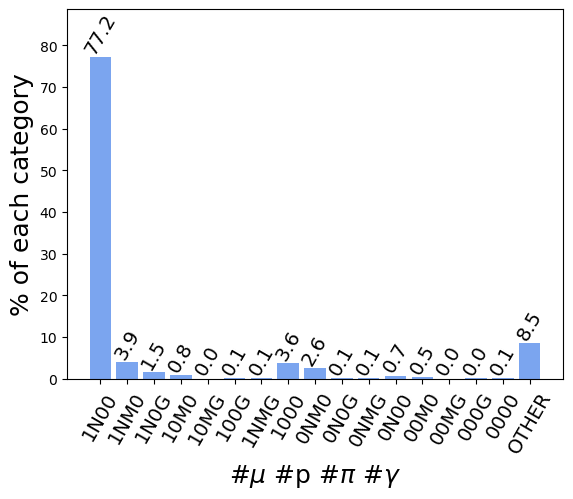

In [2]:

true_slice_class=[]
for i,slice in enumerate(slices):
    if slice['reco_class'].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in slice['reco_class']]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        if slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' :
            returned_srting = 'OTHER'
        else :
            true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
            nprotons = '0'
            npions = '0'
            nshowers = '0'
            if true[1] == 0 : nprotons = '0' 
            else : nprotons = 'N'
            if true[2] == 0 : npions = '0' 
            else : npions = 'M'
            if true[3] + true[4] == 0 : nshowers = '0' 
            else : nshowers = 'G'

            returned_srting = r'{}{}{}{}'.format(str(true[0]),nprotons,npions,nshowers)
        
        #if returned_srting == '1000' : 
        #    selected_protons = info_selected_tracks_newPID[i]['protons']
        #    ek = []
        #    for pro in selected_protons:
        #        ek.append(pro['Ekpro'])
        #    print(np.max(ek))
            #print(slice['run'],slice['evt'],slice['slice_number'])
        true_slice_class.append(returned_srting)

custom_order = ['1N00', '1NM0', '1N0G', '10M0', '10MG', '100G', '1NMG', '1000', '0NM0', '0N0G', '0NMG', '0N00', '00M0', '00MG', '000G', '0000', 'OTHER']

counts = Counter(true_slice_class)
total_events = sum(counts.values())
relative_counts = {k: v/total_events*100 for k, v in counts.items()}

couts_in_order = [relative_counts[k] for k in custom_order]

bars = plt.bar(custom_order, couts_in_order,color='cornflowerblue',alpha=0.85)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # centro della barra
        height,                           # altezza della barra
        f'{height:.1f}',                 # testo in percentuale
        ha='center', va='bottom',         # allineamento
        rotation=60,                       # rotazione etichetta
        fontsize = 14
    )

plt.xticks(rotation=60,fontsize=14)
#plt.bar_label(bars, padding=3,fmt='%.1f',fontsize=14)
plt.xlabel(r'#$\mu$ #p #$\pi$ #$\gamma$', fontsize=18)
plt.ylabel('% of each category',fontsize=18)
plt.ylim(0, max(relative_counts.values())*1.15)
plt.savefig('prova_purity_depE25.pdf',format='pdf',bbox_inches='tight')

In [ ]:
from collections import Counter
true_slice_class=[]
for i,slice in enumerate(slices):
    if reco_class_newPID[i].startswith('bad_slice')==True :  continue
    reco = [int(char) for char in reco_class_newPID[i]]
    if reco[0] == 1 and reco[1] >= 1 and reco[2] == 0 and reco[3] == 0 : 
        if slice['true_slice_classifications'] == 'not_in_FV' or slice['true_slice_classifications'] == 'not_in_Active' or slice['true_slice_classifications'] == 'not_contained' or slice['true_slice_classifications'] == "cosmic" or slice['true_slice_classifications']=='reco_vertex_isNAN' or  slice['true_slice_classifications']=='true_vertex_isNAN' or slice['true_slice_classifications']=='not_numu' :
            returned_srting = 'OTHER'
        else :
            true = [int(char) for j,char in enumerate(slice['true_slice_classifications']) if j <= 4]
            nprotons = '0'
            npions = '0'
            nshowers = '0'
            if true[1] == 0 : nprotons = '0' 
            else : nprotons = 'N'
            if true[2] == 0 : npions = '0' 
            else : npions = 'M'
            if true[3] + true[4] == 0 : nshowers = '0' 
            else : nshowers = 'G'

            returned_srting = r'{}{}{}{}'.format(str(true[0]),nprotons,npions,nshowers)
        
        #if returned_srting == '1000' : 
        #    selected_protons = info_selected_tracks_newPID[i]['protons']
        #    ek = []
        #    for pro in selected_protons:
        #        ek.append(pro['Ekpro'])
        #    print(np.max(ek))
            #print(slice['run'],slice['evt'],slice['slice_number'])
        true_slice_class.append(returned_srting)

custom_order = ['1N00', '1NM0', '1N0G', '10M0', '10MG', '100G', '1NMG', '1000', '0NM0', '0N0G', '0NMG', '0N00', '00M0', '00MG', '000G', '0000', 'OTHER']

counts = Counter(true_slice_class)
total_events = sum(counts.values())
relative_counts = {k: v/total_events*100 for k, v in counts.items()}

couts_in_order = [relative_counts[k] for k in custom_order]

bars = plt.bar(custom_order, couts_in_order,color='cornflowerblue',alpha=0.85)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # centro della barra
        height,                           # altezza della barra
        f'{height:.1f}',                 # testo in percentuale
        ha='center', va='bottom',         # allineamento
        rotation=60,                       # rotazione etichetta
        fontsize = 14
    )

plt.xticks(rotation=60,fontsize=14)
#plt.bar_label(bars, padding=3,fmt='%.1f',fontsize=14)
plt.xlabel(r'#$\mu$ #p #$\pi$ #$\gamma$', fontsize=18)
plt.ylabel('% of each category',fontsize=18)
plt.ylim(0, max(relative_counts.values())*1.15)
#plt.savefig('prova_purity.pdf',format='pdf',bbox_inches='tight')